In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/global_green_energy_pulse_20260112.csv")

print("Kích thước dữ liệu:", df.shape)

df.head()

Kích thước dữ liệu: (1920, 7)


,city,time,shortwave_radiation,wind_speed_100m,green_score,latitude,longitude
0,New York,2026-01-05 00:00:00,0.0,22.9,0.763333,40.71,-74.0
1,New York,2026-01-05 01:00:00,0.0,23.4,0.780000,40.71,-74.0
2,New York,2026-01-05 02:00:00,0.0,28.2,0.940000,40.71,-74.0
3,New York,2026-01-05 03:00:00,0.0,30.0,1.000000,40.71,-74.0
4,New York,2026-01-05 04:00:00,0.0,29.7,0.990000,40.71,-74.0


In [ ]:
print("\nThông tin dataset:")
df.info()


Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 1920 non-null   object 
 1   time                 1920 non-null   object 
 2   shortwave_radiation  1920 non-null   float64
 3   wind_speed_100m      1920 non-null   float64
 4   green_score          1920 non-null   float64
 5   latitude             1920 non-null   float64
 6   longitude            1920 non-null   float64
dtypes: float64(5), object(2)
memory usage: 105.1+ KB


In [ ]:
print("\nSố giá trị thiếu:")
print(df.isnull().sum())


Số giá trị thiếu:
city                   0
time                   0
shortwave_radiation    0
wind_speed_100m        0
green_score            0
latitude               0
longitude              0
dtype: int64


In [ ]:
df_clean = df[[
    'shortwave_radiation',
    'wind_speed_100m',
    'green_score'
]].dropna()

print("Số dòng sau khi làm sạch:", df_clean.shape)

Số dòng sau khi làm sạch: (1920, 3)


In [ ]:
x = df_clean['shortwave_radiation']
y = df_clean['green_score']

print("Số mẫu:", len(df_clean))

Số mẫu: 1920


In [ ]:
corr, p_value = pearsonr(x, y)

r_squared = corr**2
n = len(x)

print("==============================")
print("KẾT QUẢ TƯƠNG QUAN PEARSON")
print("==============================")

print(f"Số mẫu (n): {n}")
print(f"Hệ số tương quan Pearson (r): {corr:.4f}")
print(f"Hệ số xác định (R^2): {r_squared:.4f}")
print(f"P-value: {p_value:.6e}")

KẾT QUẢ TƯƠNG QUAN PEARSON
Số mẫu (n): 1920
Hệ số tương quan Pearson (r): 0.4549
Hệ số xác định (R^2): 0.2069
P-value: 1.137362e-98


In [ ]:
print("==============================")
print("DIỄN GIẢI")
print("==============================")

if p_value < 0.05:
    print("- Có mối tương quan có ý nghĩa thống kê")
else:
    print("- Không có mối tương quan có ý nghĩa")

if abs(corr) < 0.3:
    print("- Tương quan yếu")
elif abs(corr) < 0.7:
    print("- Tương quan trung bình")
else:
    print("- Tương quan mạnh")

if corr > 0:
    print("- Mối quan hệ thuận")
else:
    print("- Mối quan hệ nghịch")

DIỄN GIẢI
- Có mối tương quan có ý nghĩa thống kê
- Tương quan trung bình
- Mối quan hệ thuận


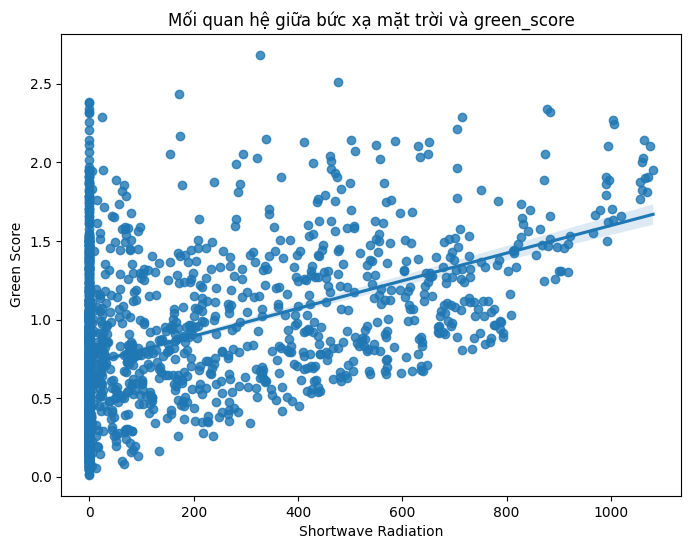

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=x,
    y=y
)

plt.title("Mối quan hệ giữa bức xạ mặt trời và green_score")
plt.xlabel("Shortwave Radiation")
plt.ylabel("Green Score")

plt.show()

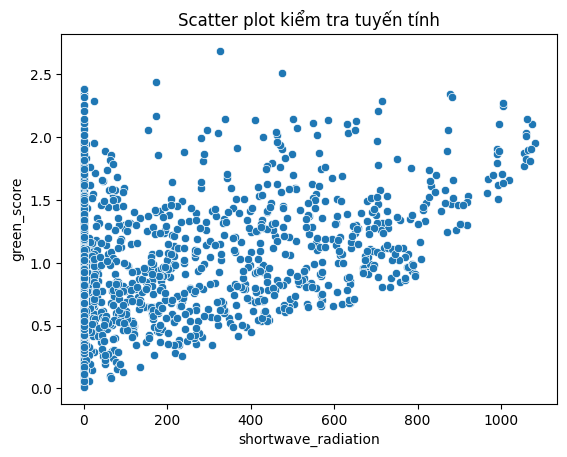

In [ ]:
sns.scatterplot(x=x, y=y)
plt.title("Scatter plot kiểm tra tuyến tính")
plt.show()